# Personal Information
Name: **Maja Kubara**

StudentID: **14498863**

Email: [**maja.kubara@student.uva.nl**](youremail@student.uva.nl)

Submitted on: **22.03.2026**

# Content
The dataset used include european environmental agency (EEA) data https://www.eea.europa.eu/en/datahub/datahubitem-view/778ef9f5-6293-4846-badd-56a29c70880d and KNMI data https://dataplatform.knmi.nl/dataset/etmaalgegevensknmistations-1. EEA data includes air quality readings from 2013 onwards and is aggregated daily. KNMI dataset spans from 1950 till present with daily meteorological readings. 

Prior to EDA the datasets were merged via distance and date variables. The distance was calculated based on coordinates available in datasets via cKDTree algorithm. After merging both dataset include data only from 2013 until end of 2025 with daily readings. As distance between stations is an important consideration, this study only includes data from stations not further than 10km to each other to account for spatial discrepencies.

# Data Description

The dataset includes many missing values for pollutants, over 95% of the data points. On the other hand, the meteorological data is more complete, with max of missing percentage below 41%. 

The target variable - precipitation - has only 5 available points for extreme precipitation (precipitation above 50 mm a day) for stations within 10 km distance. It can be seen that for station 340 the readings are faulty as there are no other values than close to 0. It is important to note that some EEA stations got assigned the same KNMI station based on distance, therefore there may be duplicates for KNMI stations. Perhaps in further data cleaning, the tree algorithm could be updated to only assign each station once. Monthly analysis of precipitation shows that the winter season has the highest average daily precipitation levels. Precipitation has a right-skewed distribution as expected, which doesn't affect the modelling process as XGBoost and SVM algorithms work well with non-linear and not normally distributed data. However, the small amount of data points for extreme precipitation poses a challenge, and will require data simulation to ensure that there are enough data points for prediction of extreme precipitation.

There are no clear patterns in scaterplots for meteorological data and precipitation, however, looking at the correlation plots via spearman method, it can be seen that average wind speed (FHVEC) has a correlation of 0.3, relative humidity (UG) of 0.36 and Reference crop evapotranspiration (EV24) of -0.38 with precipitation (RH). The pollutant data includes many error readings that have data points below 0, after filtering the wrong readings out, it can be seen that the pollutant data is right-skewed. Moreover, for the precipitation above 50mm there is only one reading per each pollutant available. Due to high missing percentage of pollutant data, the data points cannot be dropped but rather interpolated or simulated. It could be done via distribution sampling or ML learning algorithms to account for changes overtime. However, since in this study primarly focuses on classification without analysing time period, the first approach is more suitable. The independent variables meet the XGBoost and SVM assumptions.

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

In [2]:
data = pd.read_parquet("data/air_quality_with_meteorological_data.parquet")

# Change from long to wide format for easier analysis

# Create a unique row ID for easier pivoting
data['_row_id'] = range(len(data))

# Pivot without aggregation 
wide_partial = data.pivot(
    index='_row_id',
    columns='notation',
    values='Value'
).reset_index()

# Merge metadata back
metadata_cols = [c for c in data.columns if c not in ['Value', 'notation']]
wide_partial = wide_partial.merge(data[metadata_cols], left_on='_row_id', right_index=True)

# Drop the helper column
wide_partial.drop(columns=['_row_id'], inplace=True)

# Delete duplicates
wide_partial = wide_partial.drop_duplicates(subset=['Anthanthrene', 'BaP in PM2.5', 'Benzo(e)pyrene in PM10', 'Dibenzo(al)pyrene', 'H2S', 'Ni in PM2.5',
              'DDVEC', 'FHVEC', 'TG', 'UG', 'EV24', 'PG', 'RH','AQstation_id', 'KNMI_station_id', 'Date'], keep='first')

In [3]:
# Further duplication removal through grouping to keep unique records in single row, based on date and station IDs, keeping the first non-null value for each measurement
# Columns that identify a unique day/station
id_cols = ['Date', 'KNMI_station_id', 'AQstation_id']

# Columns with measurements
measurement_cols = ['Anthanthrene', 'BaP in PM2.5', 'Benzo(e)pyrene in PM10', 
                    'Dibenzo(al)pyrene', 'H2S', 'Ni in PM2.5', 'DDVEC', 'FHVEC',
                    'TG', 'UG', 'EV24', 'PG', 'RH']

# Group by date + stations
wide_clean = wide_partial.groupby(id_cols, as_index=False).agg(
    {col: lambda x: x.dropna().iloc[0] if len(x.dropna()) > 0 else pd.NA for col in measurement_cols}
)

# Keep the metadata columns by taking the first non-null value for each group
metadata_cols = [c for c in wide_partial.columns if c not in measurement_cols + id_cols]
for col in metadata_cols:
    wide_clean[col] = wide_partial.groupby(id_cols)[col].first().values

# filter by distance
filtered_data = wide_clean[wide_clean["distance_km"] <= 10]

# Fill remaining NaN values with np.nan for matplotlib
filtered_data = filtered_data.fillna(np.nan)

### Analysis 1: Target variable - precipitation and summary stats


In [4]:
summary_stats = pd.DataFrame({
    "data count": filtered_data.count(),
    "missing values": filtered_data.isnull().sum(),
    "percentage missing": (filtered_data.isnull().sum() / len(filtered_data)) * 100})

In [5]:
summary_stats

,data count,missing values,percentage missing
Date,16780,0,0.000000
KNMI_station_id,16780,0,0.000000
AQstation_id,16780,0,0.000000
Anthanthrene,365,16415,97.824791
BaP in PM2.5,365,16415,97.824791
Benzo(e)pyrene in PM10,365,16415,97.824791
Dibenzo(al)pyrene,365,16415,97.824791
H2S,365,16415,97.824791
Ni in PM2.5,730,16050,95.649583
DDVEC,10030,6750,40.226460


C:\Users\majak\AppData\Local\Temp\ipykernel_5956\2605171065.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
C:\Users\majak\AppData\Local\Temp\ipykernel_5956\2605171065.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
C:\Users\majak\AppData\Local\Temp\ipykernel_5956\2605171065.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()
C:\Users\majak\AppData\Local\Temp\ipykernel_5956\2605171065.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argum

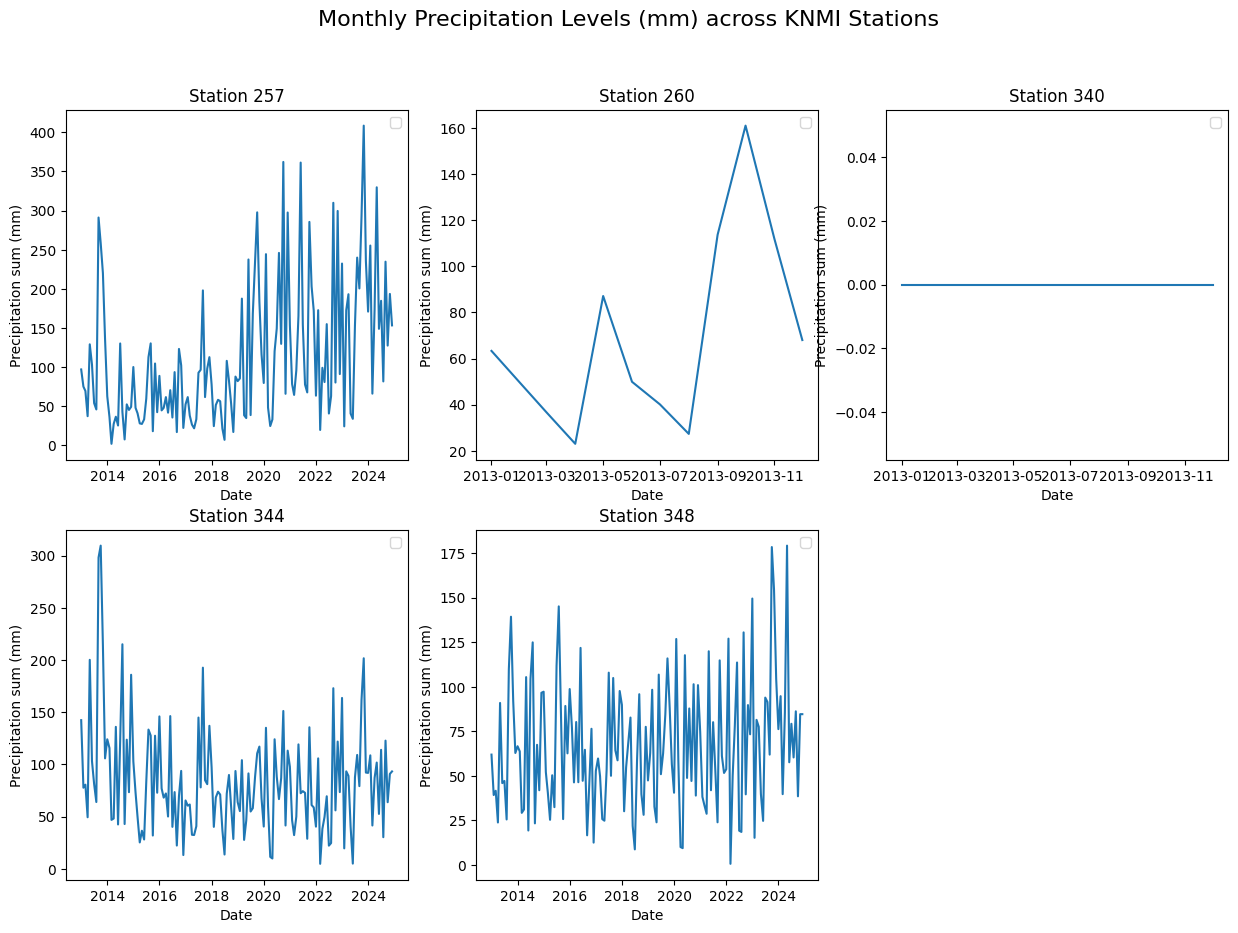

<Figure size 640x480 with 0 Axes>

In [6]:
# Precipitation levels (RH) overtime across stations
KNMI_stations = list(np.unique(filtered_data["KNMI_station_id"]))

n_col = 3
n_row = int(np.ceil(len(KNMI_stations) / n_col))
fig, axes = plt.subplots(n_row, n_col, figsize=(15, 5 * n_row))
axes = axes.flatten()

# Plot monthly precipitation levels for each station
for i, station in enumerate(KNMI_stations):
    station_data = filtered_data[filtered_data["KNMI_station_id"] == station]
    monthly = station_data.groupby(station_data["Date"].dt.to_period("M"))["RH"].sum()
    axes[i].plot(monthly.index.to_timestamp(), monthly.values)
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Precipitation sum (mm)")
    axes[i].set_title(f"Station {station}")
    axes[i].legend() 

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  
fig.suptitle("Monthly Precipitation Levels (mm) across KNMI Stations", fontsize=16)

plt.show()
plt.tight_layout()

C:\Users\majak\AppData\Local\Temp\ipykernel_5956\3054088839.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


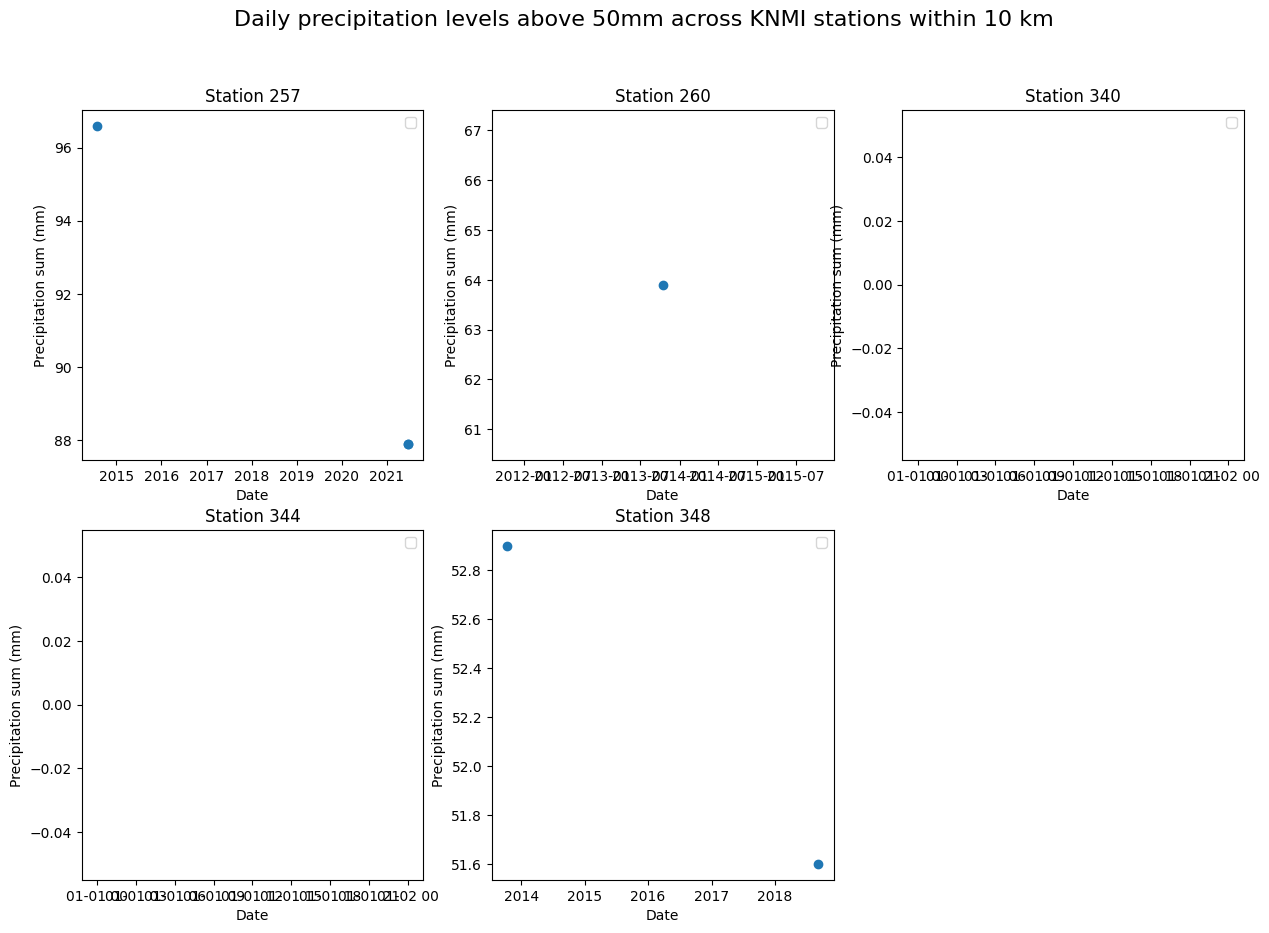

<Figure size 640x480 with 0 Axes>

In [7]:
# Plot daily precipitation levels above 50mm for each station
n_col = 3
n_row = int(np.ceil(len(KNMI_stations) / n_col))
fig, axes = plt.subplots(n_row, n_col, figsize=(15, 5 * n_row))
axes = axes.flatten()

for i, station in enumerate(KNMI_stations):
    station_data = filtered_data[(filtered_data["KNMI_station_id"] == station) & (filtered_data["RH"] >= 50)]

    axes[i].scatter(station_data["Date"], station_data["RH"])
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Precipitation sum (mm)")
    axes[i].set_title(f"Station {station}")
    axes[i].legend() 

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  
fig.suptitle("Daily precipitation levels above 50mm across KNMI stations within 10 km", fontsize=16)

plt.show()
plt.tight_layout()

In [8]:
# Variables to inspect when precipitation > 50mm
columns = ['Anthanthrene', 'BaP in PM2.5', 'Benzo(e)pyrene in PM10', 'Dibenzo(al)pyrene', 'H2S', 'Ni in PM2.5',
              'DDVEC', 'FHVEC', 'TG', 'UG', 'EV24', 'PG', 'RH', 'Date', 'KNMI_station_id', 'AQstation_id'] 

# Filter data where precipitation > 50 mm
extreme_precip = filtered_data[filtered_data["RH"] > 50]

extreme_precip[columns].sort_values(by="RH")

,Anthanthrene,BaP in PM2.5,Benzo(e)pyrene in PM10,Dibenzo(al)pyrene,H2S,Ni in PM2.5,DDVEC,FHVEC,TG,UG,EV24,PG,RH,Date,KNMI_station_id,AQstation_id
15943,NaN,NaN,NaN,NaN,NaN,NaN,13.0,2.8,19.0,88.0,2.1,1016.900024,51.600002,2018-09-06,348,NL00644
4845,NaN,NaN,NaN,NaN,NaN,NaN,159.0,8.6,8.6,93.0,0.1,1010.0,52.900002,2013-10-14,348,NL00644
4836,1.420000000000000000,3.030000000000000000,-888.000000000000000000,-888.000000000000000000,0.780000000000000000,NaN,149.0,6.5,8.3,95.0,0.1,1010.900024,63.900002,2013-10-14,260,NL00639
20909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.4,89.0,2.8,NaN,87.900002,2021-06-19,257,NL00551
20910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.4,89.0,2.8,NaN,87.900002,2021-06-19,257,NL00553
8686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.0,92.0,2.1,NaN,96.599998,2014-07-29,257,NL00553


<Axes: title={'center': 'Average Monthly Precipitation Across Years'}, xlabel='Date'>

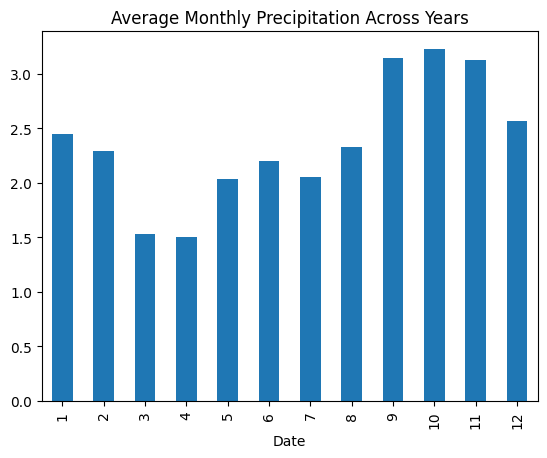

In [9]:
# Average monthly precipitation across years
monthly_avg = filtered_data.groupby(filtered_data["Date"].dt.month)["RH"].mean()
monthly_avg.plot(kind="bar", title="Average Monthly Precipitation Across Years")

<Axes: title={'center': 'Annual Maximum Precipitation across stations'}, xlabel='Date'>

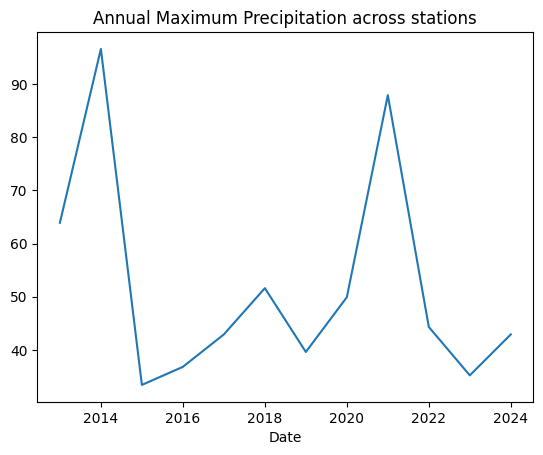

In [10]:
# Annual maximum precipitation across stations
annual_max = filtered_data.groupby(filtered_data["Date"].dt.year)["RH"].max()
annual_max.plot(title="Annual Maximum Precipitation across stations")

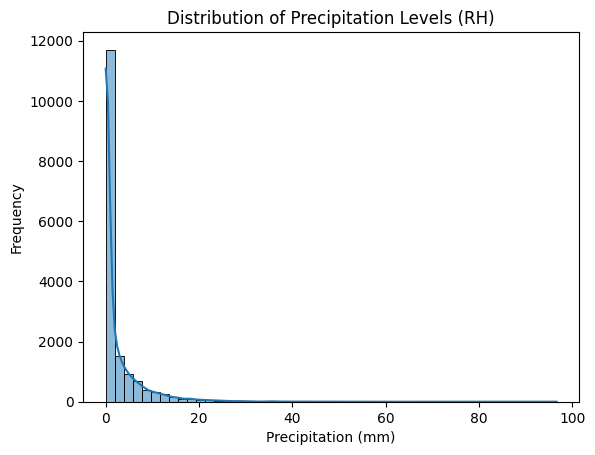

In [11]:
# Distribution of precipitation levels (RH)
sns.histplot(filtered_data["RH"], bins=50, kde=True)
plt.title("Distribution of Precipitation Levels (RH)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.show()

### Analysis 2: Target and independent variables

C:\Users\majak\AppData\Local\Temp\ipykernel_5956\2963827313.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


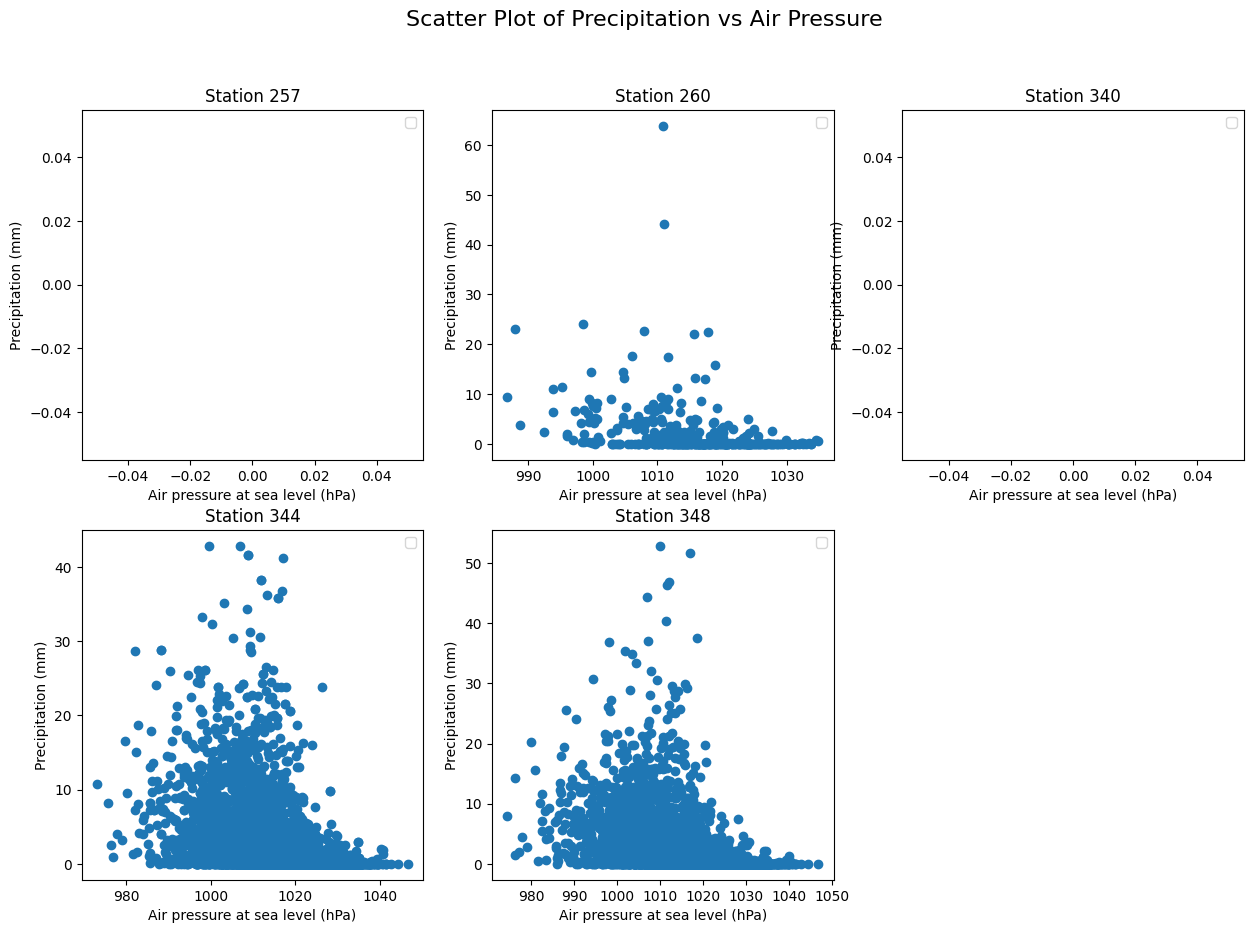

<Figure size 640x480 with 0 Axes>

In [ ]:
# Scatter plot of precipitation levels (RH) vs air pressure at sea level (PG) for each station

n_col = 3
n_row = int(np.ceil(len(KNMI_stations) / n_col))
fig, axes = plt.subplots(n_row, n_col, figsize=(15, 5 * n_row))
axes = axes.flatten()

# Plot monthly precipitation levels for each station
for i, station in enumerate(KNMI_stations):
    station_data = filtered_data[filtered_data["KNMI_station_id"] == station]
    axes[i].scatter(station_data["PG"], station_data["RH"])
    axes[i].set_xlabel("Air pressure at sea level (hPa)")
    axes[i].set_ylabel("Precipitation (mm)")
    axes[i].set_title(f"Station {station}")
    axes[i].legend() 

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  
fig.suptitle("Scatter Plot of Precipitation vs Air Pressure", fontsize=16)

plt.show()
plt.tight_layout()

C:\Users\majak\AppData\Local\Temp\ipykernel_5956\962942459.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


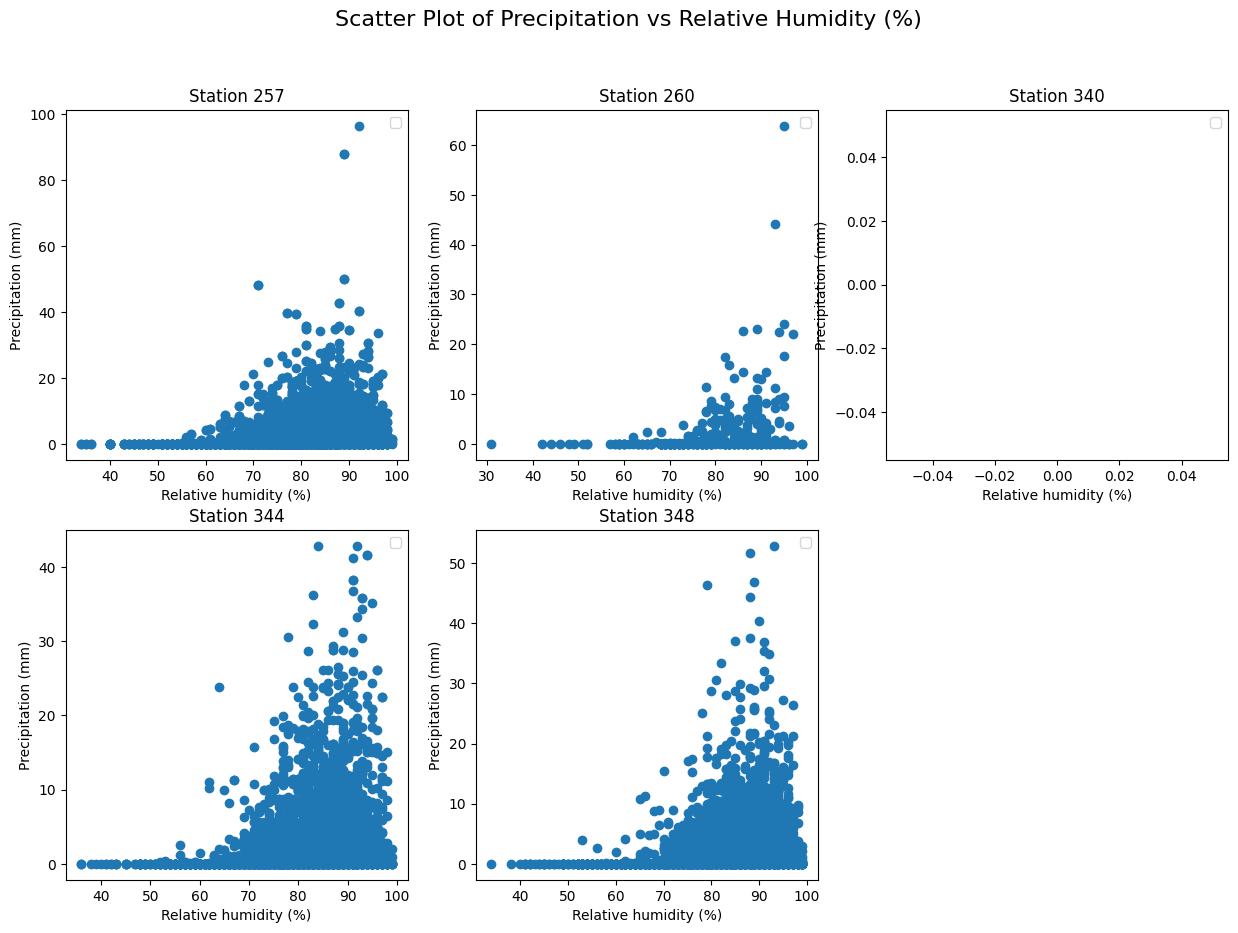

<Figure size 640x480 with 0 Axes>

In [13]:
# Scatter plot of precipitation levels (RH) vs air pressure at sea level (PG) for each station

n_col = 3
n_row = int(np.ceil(len(KNMI_stations) / n_col))
fig, axes = plt.subplots(n_row, n_col, figsize=(15, 5 * n_row))
axes = axes.flatten()

# Plot monthly precipitation levels for each station
for i, station in enumerate(KNMI_stations):
    station_data = filtered_data[filtered_data["KNMI_station_id"] == station]
    axes[i].scatter( station_data["UG"],station_data["RH"])
    axes[i].set_xlabel("Relative humidity (%)")
    axes[i].set_ylabel("Precipitation (mm)")
    axes[i].set_title(f"Station {station}")
    axes[i].legend() 

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  
fig.suptitle("Scatter Plot of Precipitation vs Relative Humidity (%)", fontsize=16)

plt.show()
plt.tight_layout()

C:\Users\majak\AppData\Local\Temp\ipykernel_5956\2416210450.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


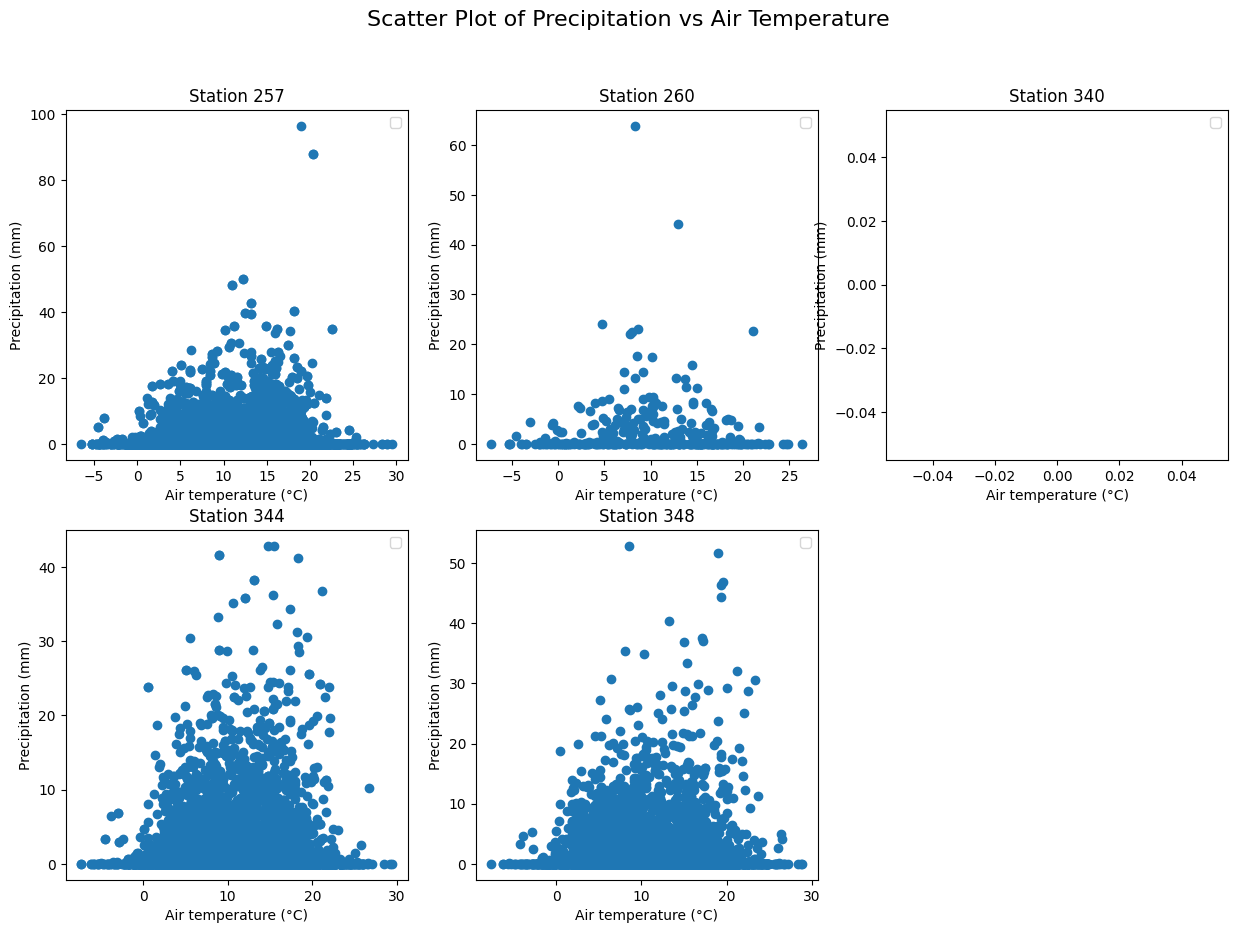

<Figure size 640x480 with 0 Axes>

In [14]:
# Scatter plot of precipitation levels (RH) vs air pressure at sea level (PG) for each station

n_col = 3
n_row = int(np.ceil(len(KNMI_stations) / n_col))
fig, axes = plt.subplots(n_row, n_col, figsize=(15, 5 * n_row))
axes = axes.flatten()

# Plot monthly precipitation levels for each station
for i, station in enumerate(KNMI_stations):
    station_data = filtered_data[filtered_data["KNMI_station_id"] == station]
    axes[i].scatter( station_data["TG"],station_data["RH"])
    axes[i].set_xlabel("Air temperature (°C)")
    axes[i].set_ylabel("Precipitation (mm)")
    axes[i].set_title(f"Station {station}")
    axes[i].legend() 

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  
fig.suptitle("Scatter Plot of Precipitation vs Air Temperature", fontsize=16)

plt.show()
plt.tight_layout()

C:\Users\majak\AppData\Local\Temp\ipykernel_5956\3617900466.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


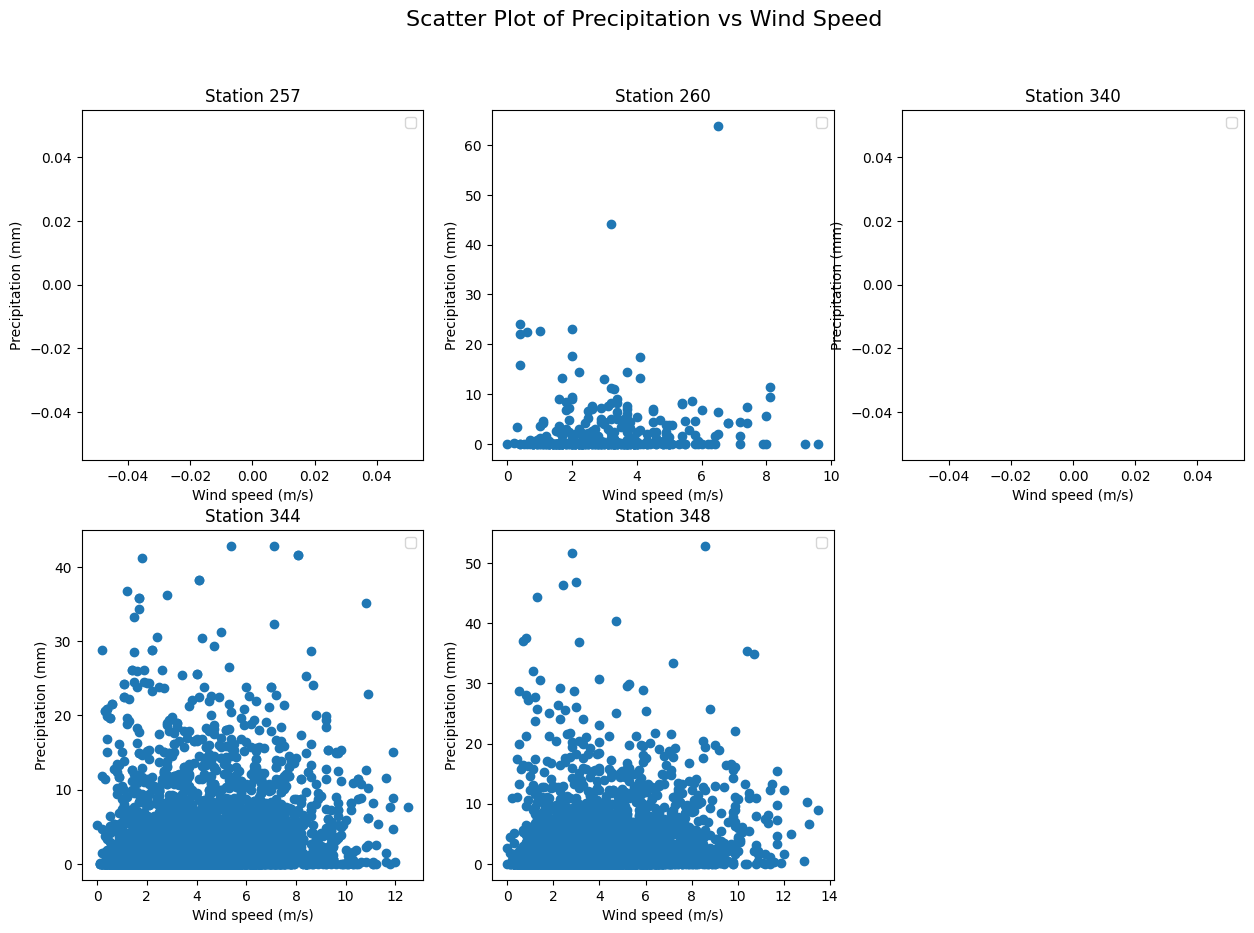

<Figure size 640x480 with 0 Axes>

In [15]:
# Scatter plot of precipitation levels (RH) vs air pressure at sea level (PG) for each station

n_col = 3
n_row = int(np.ceil(len(KNMI_stations) / n_col))
fig, axes = plt.subplots(n_row, n_col, figsize=(15, 5 * n_row))
axes = axes.flatten()

# Plot monthly precipitation levels for each station
for i, station in enumerate(KNMI_stations):
    station_data = filtered_data[filtered_data["KNMI_station_id"] == station]
    axes[i].scatter( station_data["FHVEC"],station_data["RH"])
    axes[i].set_xlabel("Wind speed (m/s)")
    axes[i].set_ylabel("Precipitation (mm)")
    axes[i].set_title(f"Station {station}")
    axes[i].legend() 

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  
fig.suptitle("Scatter Plot of Precipitation vs Wind Speed", fontsize=16)

plt.show()
plt.tight_layout()

### Analysis 4: Pollutants

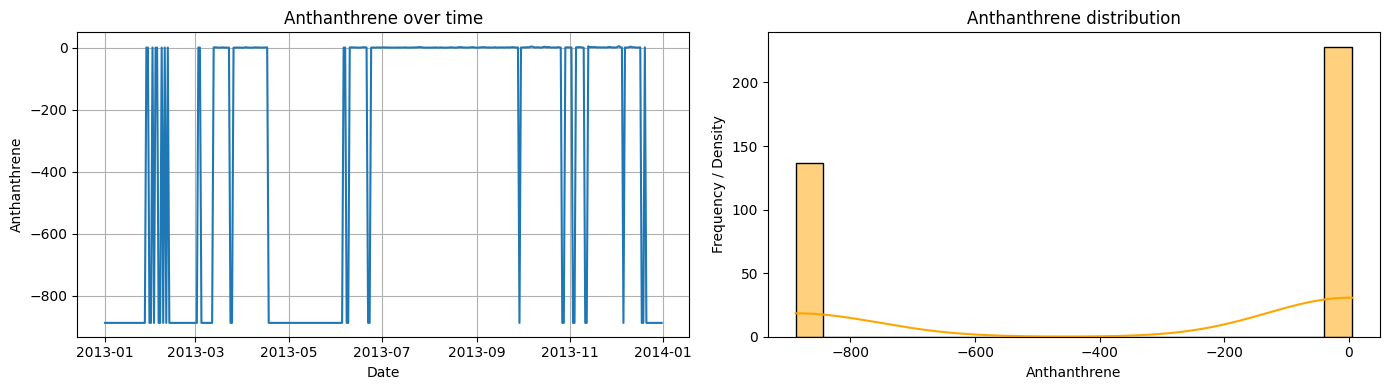

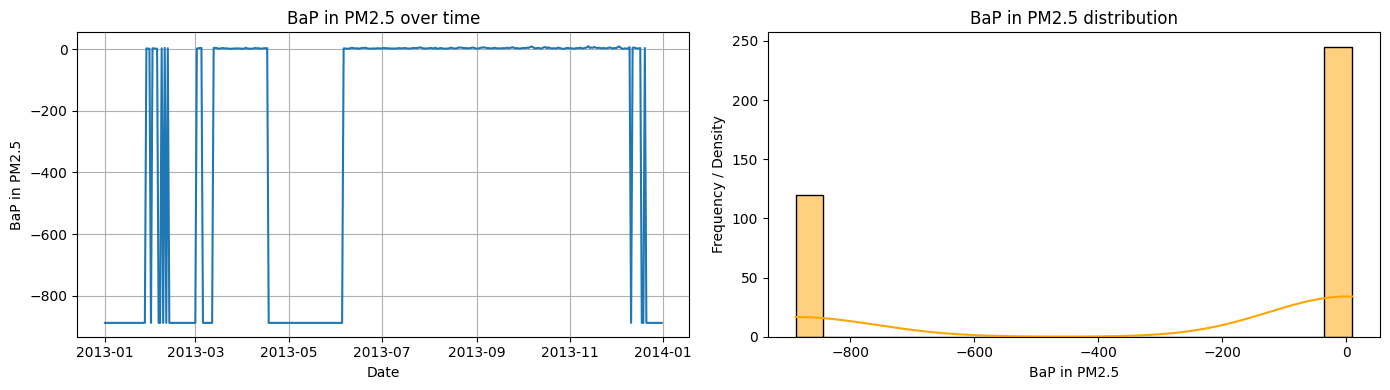

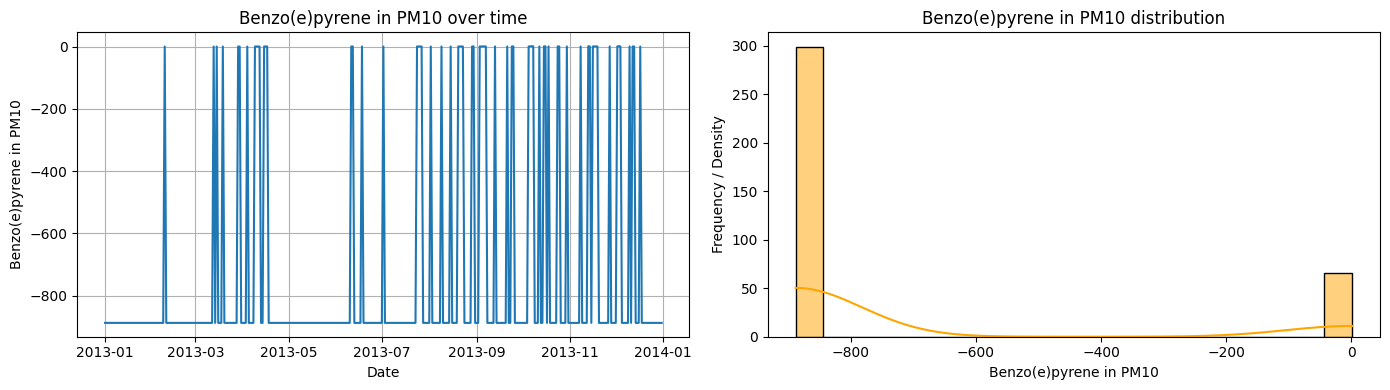

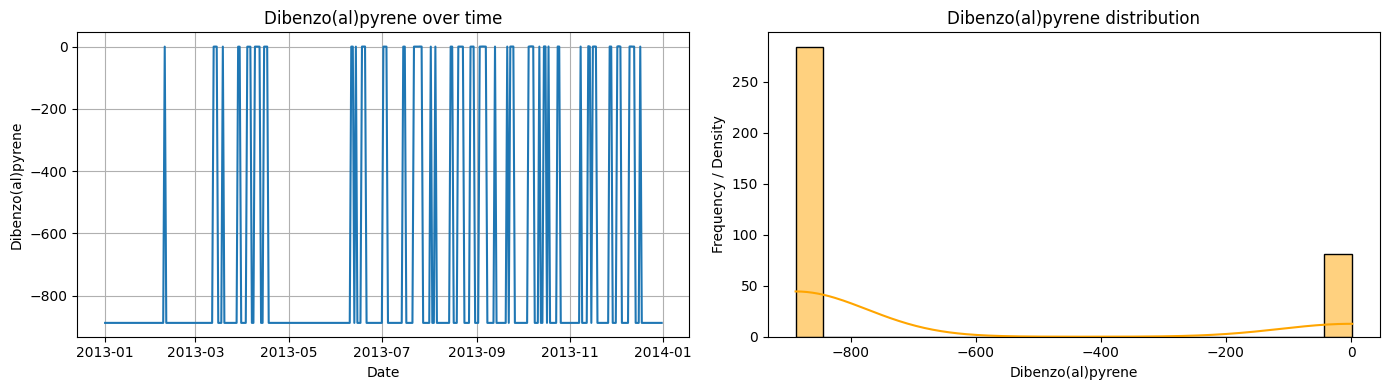

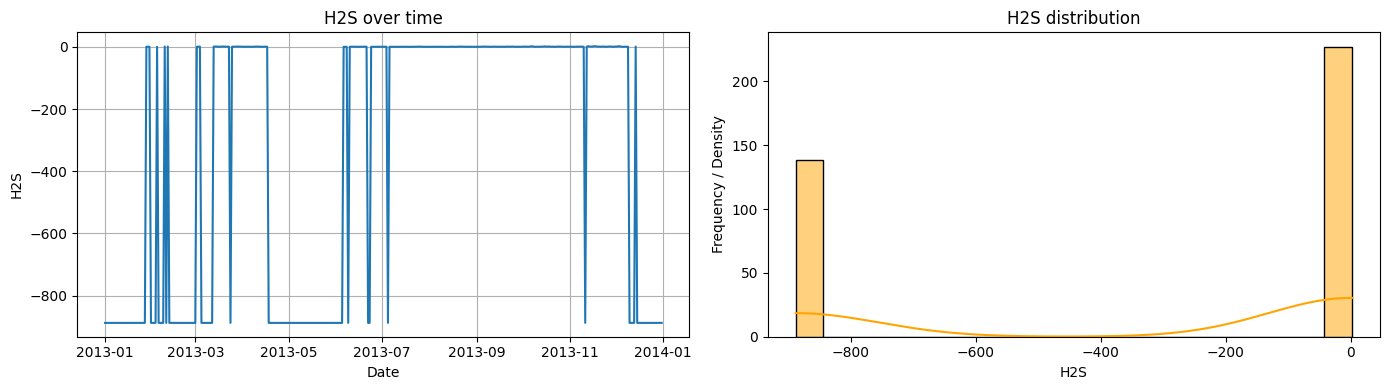

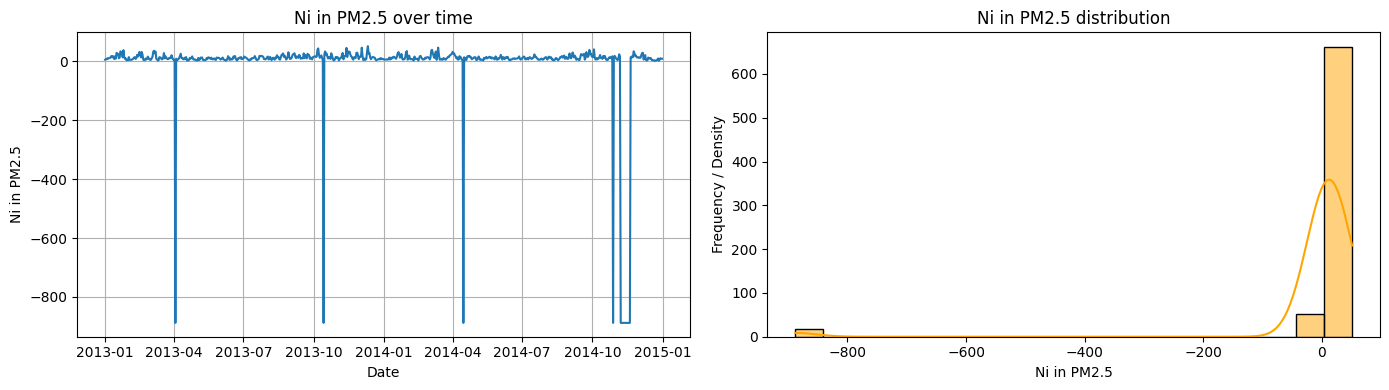

In [16]:
pollutants = ['Anthanthrene', 'BaP in PM2.5', 'Benzo(e)pyrene in PM10', 'Dibenzo(al)pyrene', 'H2S', 'Ni in PM2.5'] 

for pollutant in pollutants:

    plot_data = filtered_data.dropna(subset=[pollutant])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Line plot over time
    axes[0].plot(plot_data["Date"], plot_data[pollutant])
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel(pollutant)
    axes[0].set_title(f"{pollutant} over time")
    axes[0].grid(True)
    
    # Distribution plot
    sns.histplot(plot_data[pollutant], bins=20, kde=True, ax=axes[1], color='orange')
    axes[1].set_xlabel(pollutant)
    axes[1].set_ylabel("Frequency / Density")
    axes[1].set_title(f"{pollutant} distribution")
    
    plt.tight_layout()
    plt.show()

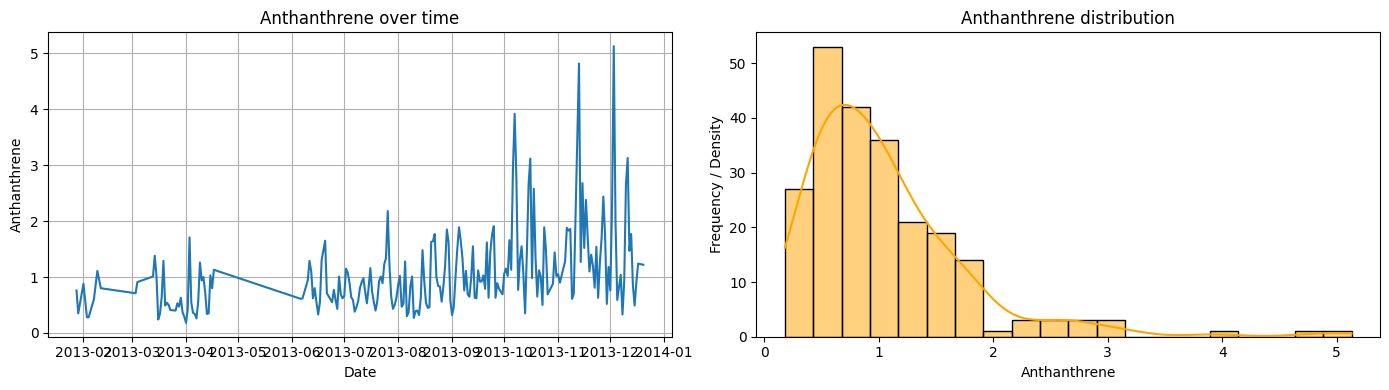

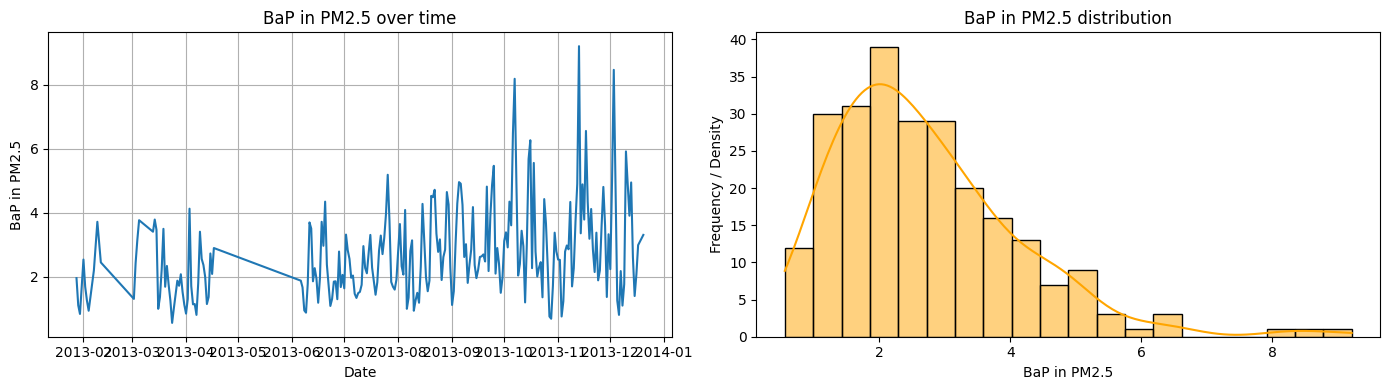

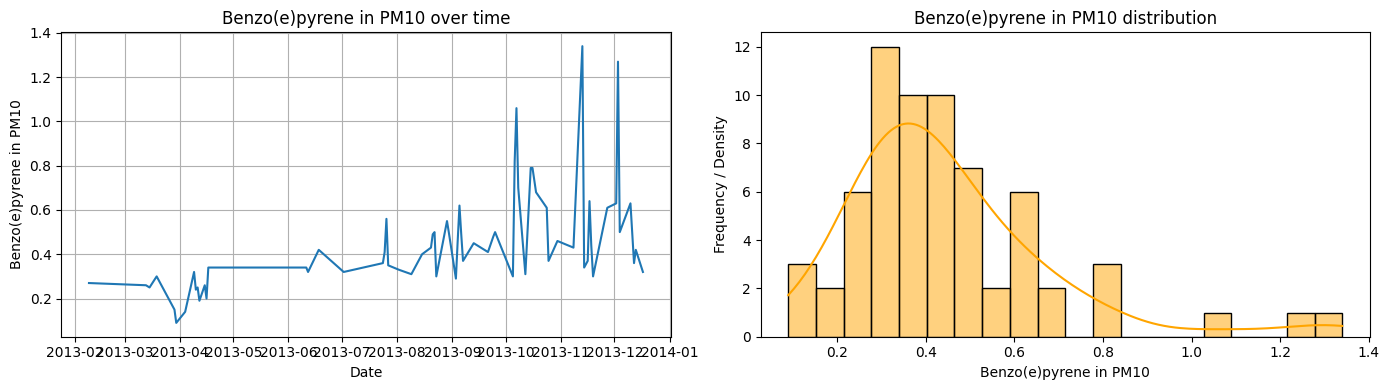

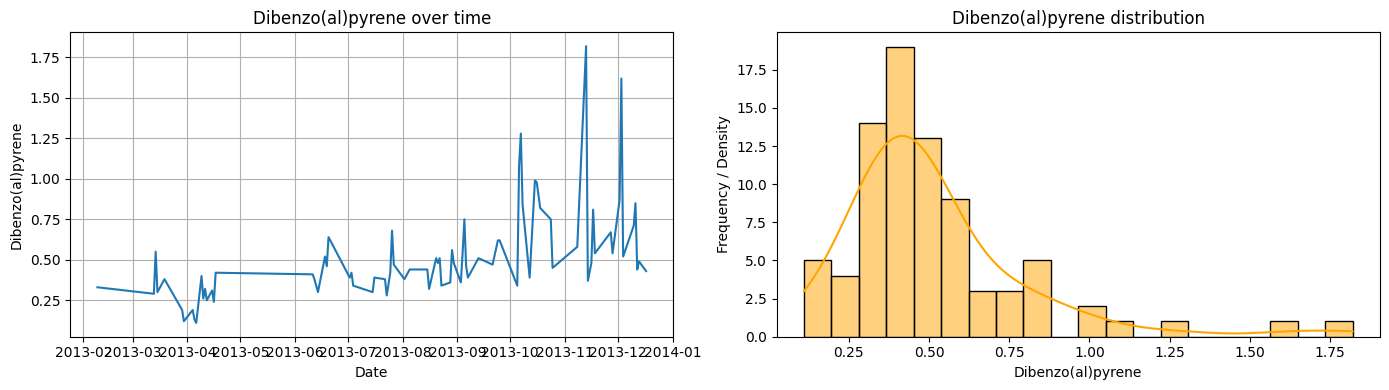

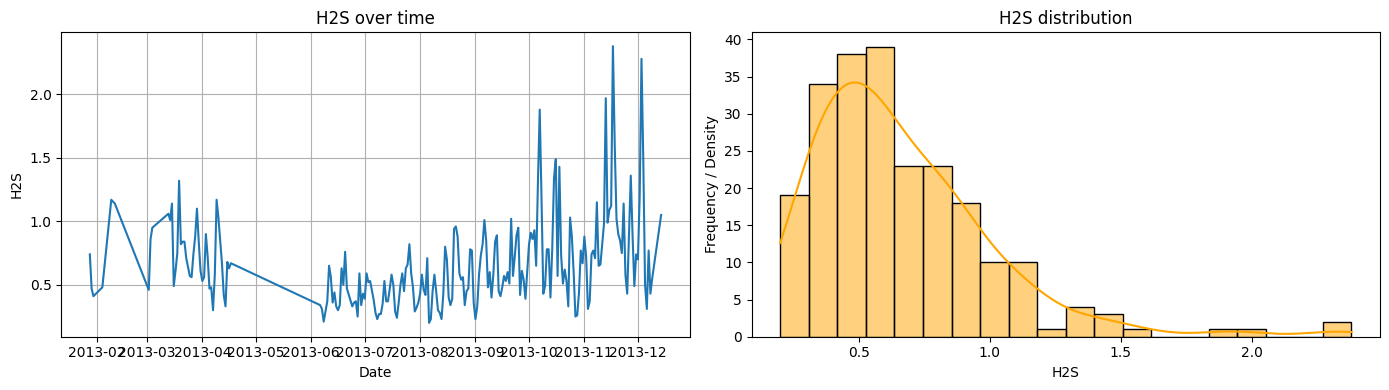

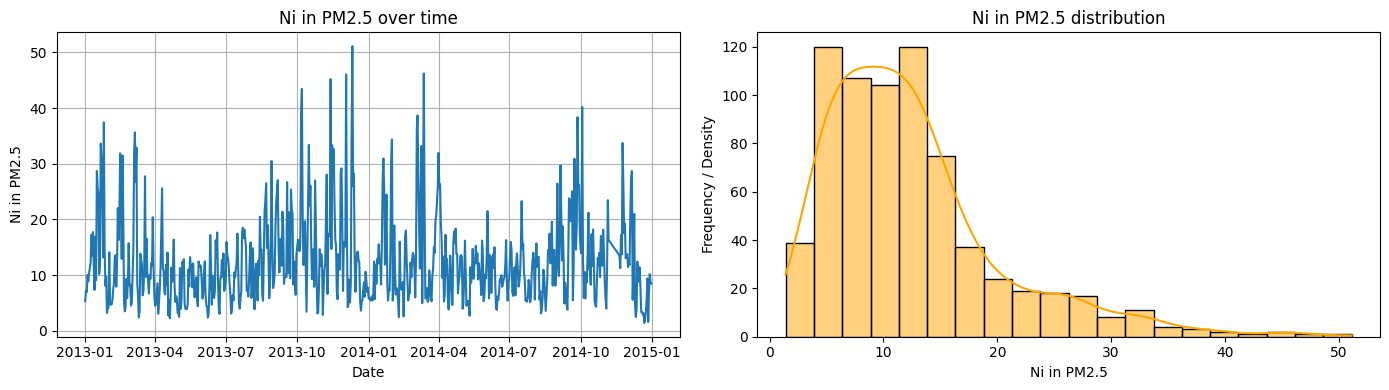

In [17]:
pollutants = ['Anthanthrene', 'BaP in PM2.5', 'Benzo(e)pyrene in PM10', 'Dibenzo(al)pyrene', 'H2S', 'Ni in PM2.5'] 

for pollutant in pollutants:

    plot_data = filtered_data.dropna(subset=[pollutant])
    plot_data = plot_data[plot_data[pollutant]>0]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Line plot over time
    axes[0].plot(plot_data["Date"], plot_data[pollutant])
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel(pollutant)
    axes[0].set_title(f"{pollutant} over time")
    axes[0].grid(True)
    
    # Distribution plot
    sns.histplot(plot_data[pollutant], bins=20, kde=True, ax=axes[1], color='orange')
    axes[1].set_xlabel(pollutant)
    axes[1].set_ylabel("Frequency / Density")
    axes[1].set_title(f"{pollutant} distribution")
    
    plt.tight_layout()
    plt.show()

### Analysis 5: Correlation

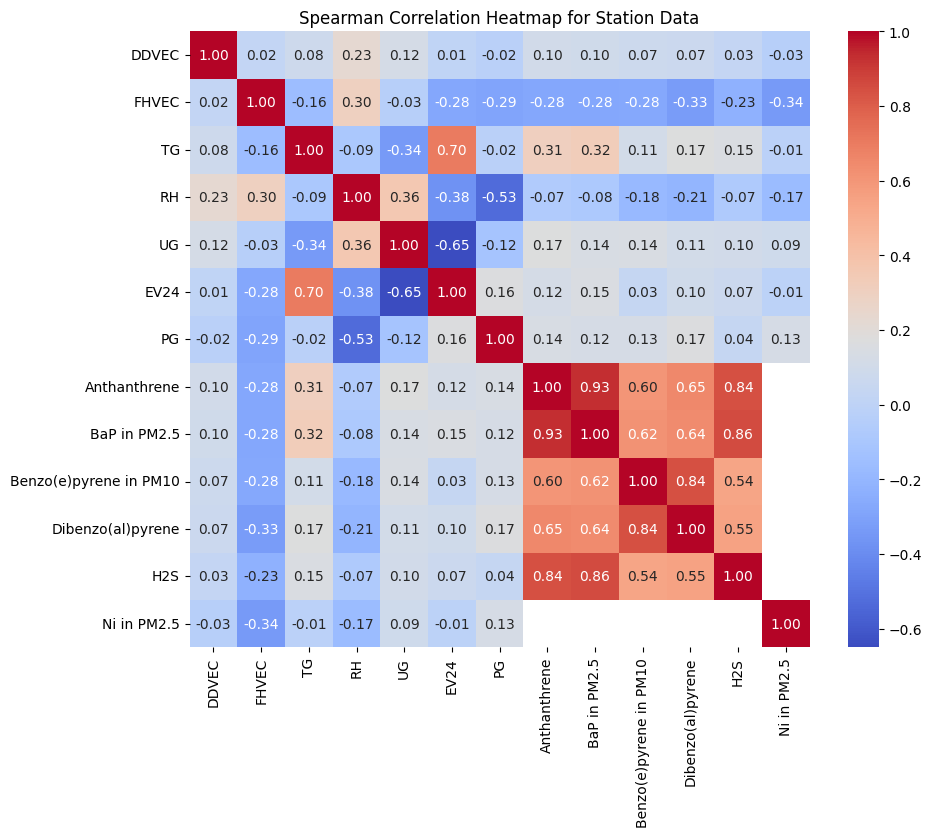

In [18]:
corr = filtered_data[["DDVEC", "FHVEC", "TG", "RH", "UG", "EV24", "PG",'Anthanthrene', 'BaP in PM2.5',
       'Benzo(e)pyrene in PM10', 'Dibenzo(al)pyrene', 'H2S', 'Ni in PM2.5']].corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Spearman Correlation Heatmap for Station Data")
plt.show()

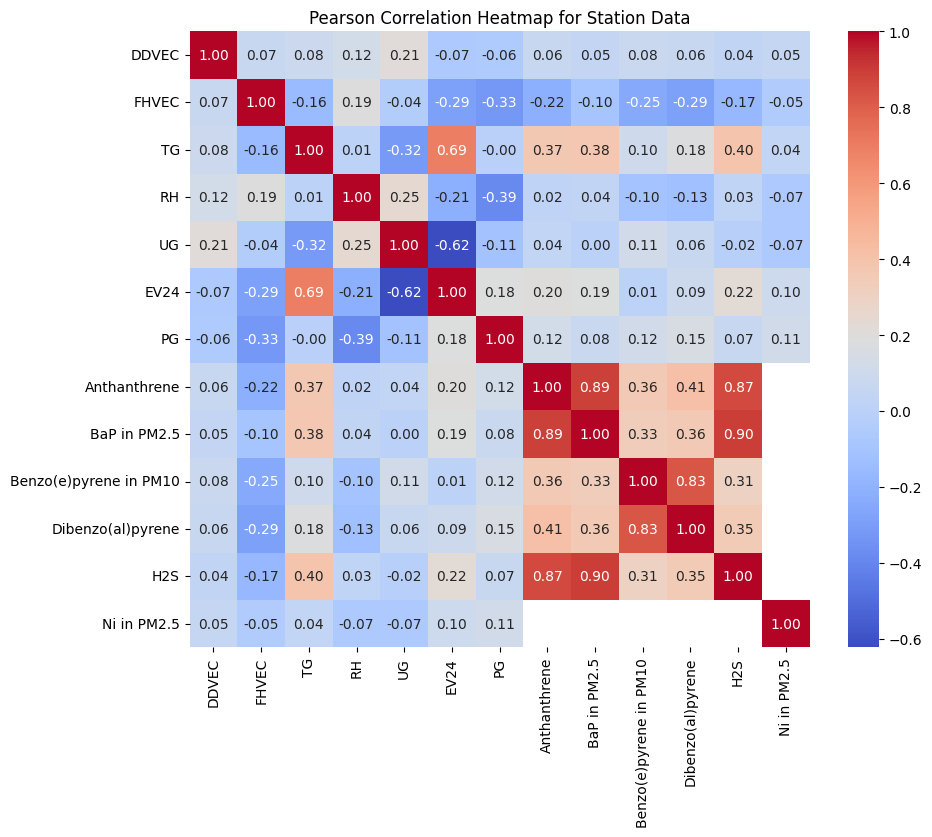

In [19]:
corr = filtered_data[["DDVEC", "FHVEC", "TG", "RH", "UG", "EV24", "PG",'Anthanthrene', 'BaP in PM2.5',
       'Benzo(e)pyrene in PM10', 'Dibenzo(al)pyrene', 'H2S', 'Ni in PM2.5']].corr(method="pearson")
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation Heatmap for Station Data")
plt.show()